# 07. Визуализация ROC-кривых всех моделей

### 1. Загрузка данных и библиотек

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import os

# Загрузка валидационных данных
X_val = np.load('../data/processed/X_val_scaled.npy')
y_val = np.load('../data/processed/y_val.npy')

### 2. Загрузка обученных моделей

In [2]:
models = {}

# Логистическая регрессия
with open('../models/logistic_regression.pkl', 'rb') as f:
    models['Logistic Regression'] = pickle.load(f)

# Случайный лес
with open('../models/random_forest.pkl', 'rb') as f:
    models['Random Forest'] = pickle.load(f)

# XGBoost
with open('../models/xgboost.pkl', 'rb') as f:
    models['XGBoost'] = pickle.load(f)

# CatBoost
with open('../models/catboost.pkl', 'rb') as f:
    models['CatBoost'] = pickle.load(f)

print("Все модели загружены.")

Все модели загружены.


### 3. Построение ROC-кривых

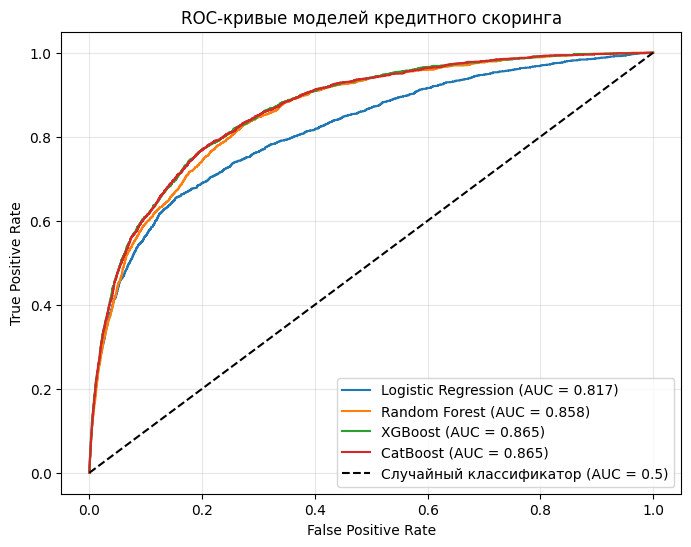

График сохранён в reports/figures/07_visualization/roc_curves_combined.png


In [3]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

# Опорная линия случайного классификатора
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей кредитного скоринга')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

# Сохранение рисунка
os.makedirs('../reports/figures/07_visualization', exist_ok=True)
plt.savefig('../reports/figures/07_visualization/roc_curves_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print("График сохранён в reports/figures/07_visualization/roc_curves_combined.png")